ZIP File Extracted Successfully!

Dataset Loaded Successfully!

   age           job  salary  marital  education targeted default  balance  \
0   58    management  100000  married   tertiary      yes      no     2143   
1   44    technician   60000   single  secondary      yes      no       29   
2   33  entrepreneur  120000  married  secondary      yes      no        2   
3   47   blue-collar   20000  married    unknown       no      no     1506   
4   33       unknown       0   single    unknown       no      no        1   

  housing loan  contact  day month  duration  campaign  pdays  previous  \
0     yes   no  unknown    5   may       261         1     -1         0   
1     yes   no  unknown    5   may       151         1     -1         0   
2     yes  yes  unknown    5   may        76         1     -1         0   
3     yes   no  unknown    5   may        92         1     -1         0   
4      no   no  unknown    5   may       198         1     -1         0   

  poutcome respo

/tmp/ipykernel_2814/4111605904.py:53: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)



Categorical Data Encoded Successfully!

Features Selected Successfully!

Train-Test Split Completed!

Model Training Completed!

========== MODEL PERFORMANCE ==========
Accuracy : 0.9
Precision: 0.64
Recall   : 0.4
F1-Score : 0.49
ROC-AUC  : 0.92

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.97      0.94      7952
           1       0.64      0.40      0.49      1091

    accuracy                           0.90      9043
   macro avg       0.78      0.68      0.72      9043
weighted avg       0.89      0.90      0.89      9043


Confusion Matrix:

[[7701  251]
 [ 653  438]]


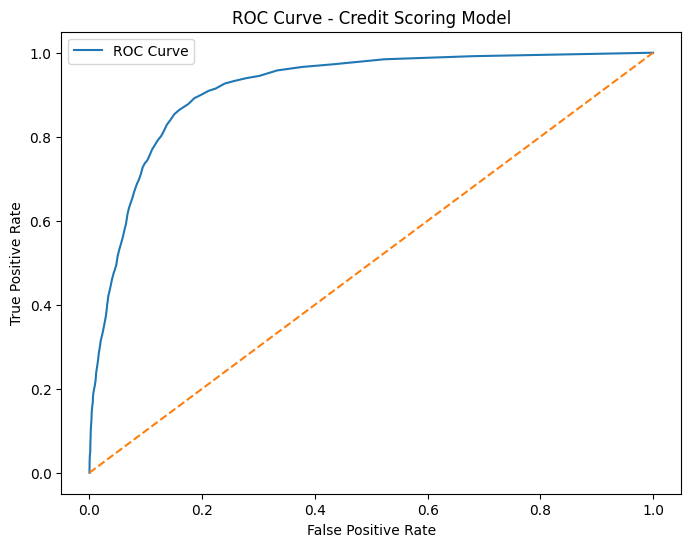


Feature Importance:

      Feature  Importance
13   duration    0.282709
7     balance    0.109143
0         age    0.103363
11        day    0.087401
12      month    0.082183
17   poutcome    0.068863
15      pdays    0.045402
14   campaign    0.038174
1         job    0.034956
2      salary    0.034700
16   previous    0.023631
8     housing    0.021628
3     marital    0.019781
4   education    0.019193
5    targeted    0.010507
9        loan    0.009447
10    contact    0.007057
6     default    0.001863


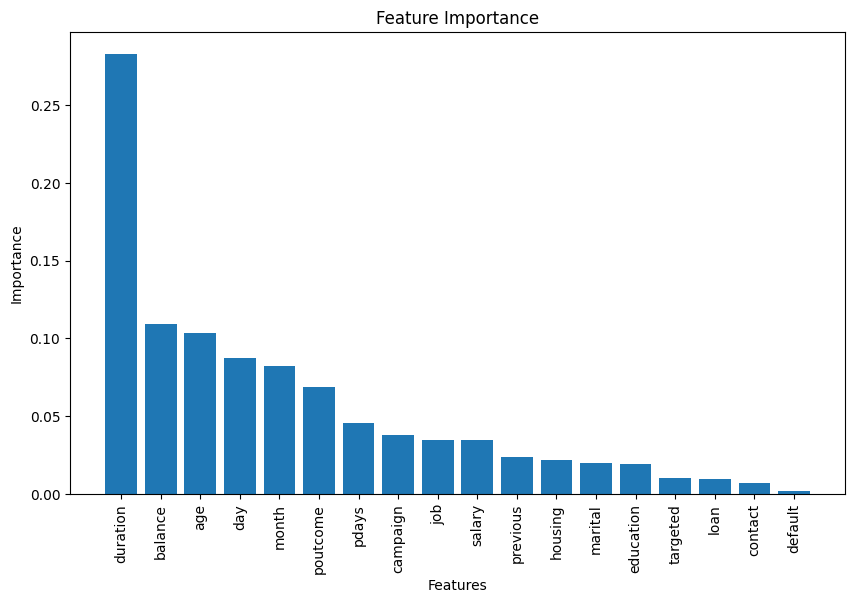


Project Completed Successfully!


In [7]:
# Import Libraries
import pandas as pd
import numpy as np
import zipfile
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

# STEP 1 : EXTRACT ZIP FILE
zip_file = 'bank-marketing.csv.zip'

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall()

print('ZIP File Extracted Successfully!')

# STEP 2 : LOAD DATASET

df = pd.read_csv('bank-marketing.csv')

print('\nDataset Loaded Successfully!\n')

# Display first 5 rows
print(df.head())

# STEP 3 : HANDLE MISSING VALUES
df.replace('unknown', np.nan, inplace=True)

# Numerical columns
num_cols = df.select_dtypes(include=np.number).columns

# Fill missing numerical values using mean
imputer = SimpleImputer(strategy='mean')

df[num_cols] = imputer.fit_transform(df[num_cols])

# Fill missing categorical values using mode
for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

print('\nMissing Values Handled Successfully!')

# STEP 4 : ENCODE CATEGORICAL DATA

label_encoder = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = label_encoder.fit_transform(df[col])

print('\nCategorical Data Encoded Successfully!')

# STEP 5 : FEATURES AND TARGET

# Target column
# In this dataset, y = customer response

target_column = 'response'

# Features
X = df.drop(target_column, axis=1)

# Target
y = df[target_column]

print('\nFeatures Selected Successfully!')

# STEP 6 : TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print('\nTrain-Test Split Completed!')

# STEP 7 : MODEL TRAINING

# Random Forest Classifier
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train Model
model.fit(X_train, y_train)

print('\nModel Training Completed!')

# STEP 8 : PREDICTIONS
# Predict test data

y_pred = model.predict(X_test)

# Probability prediction for ROC-AUC

y_prob = model.predict_proba(X_test)[:, 1]

# STEP 9 : MODEL EVALUATION

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print('\n========== MODEL PERFORMANCE ==========')

print('Accuracy :', round(accuracy, 2))
print('Precision:', round(precision, 2))
print('Recall   :', round(recall, 2))
print('F1-Score :', round(f1, 2))
print('ROC-AUC  :', round(roc_auc, 2))

# STEP 10 : CLASSIFICATION REPORT

print('\nClassification Report:\n')

print(classification_report(y_test, y_pred))

# STEP 11 : CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred)

print('\nConfusion Matrix:\n')

print(cm)

# STEP 12 : ROC CURVE


fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label='ROC Curve')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Credit Scoring Model')

plt.legend()
plt.show()

# STEP 13 : FEATURE IMPORTANCE

importance = model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print('\nFeature Importance:\n')
print(feature_importance)

# Plot Feature Importance

plt.figure(figsize=(10,6))

plt.bar(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.xticks(rotation=90)

plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('Feature Importance')

plt.show()

print('\nProject Completed Successfully!')

